In [1]:
from probrisk.utils.data import load_data1, load_data2
from bauer.models import RiskModelProbabilityDistortion
import seaborn as sns

import pytensor
# pytensor.config.compile ''
# pytensor.config.optimizer = 'None'

In [2]:
import pymc as pm

In [17]:
import matplotlib.pyplot as plt

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_8994/1902570236.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(pm.draw(x, 5000))


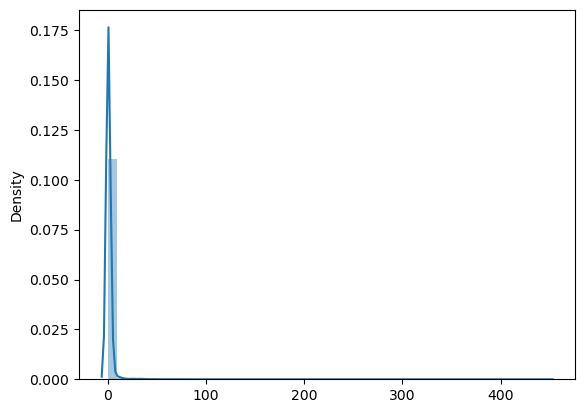

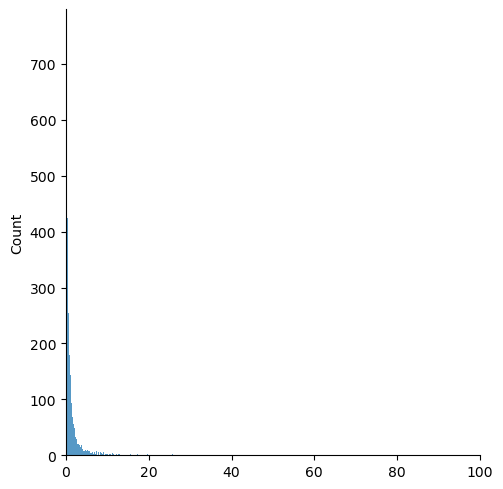

In [20]:
with pm.Model() as model:
    x = pm.HalfCauchy('a', .25)
    sns.distplot(pm.draw(x, 5000))
    y = pm.HalfCauchy('b', .5)
    sns.displot(pm.draw(y, 5000), )
    plt.xlim(0, 100)

<Axes: ylabel='Density'>

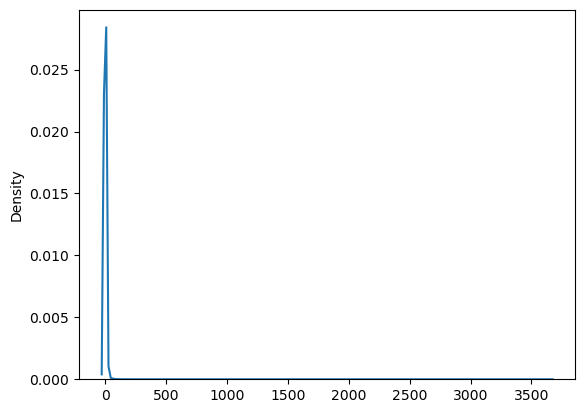

In [14]:
kk

In [10]:
dir(x)

['T',
 '__abs__',
 '__abstractmethods__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array_priority__',
 '__bool__',
 '__ceil__',
 '__class__',
 '__class_getitem__',
 '__count__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__divmod__',
 '__doc__',
 '__dot__',
 '__eq__',
 '__floor__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__iter__',
 '__le__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__orig_bases__',
 '__parameters__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdiv__',
 '__rdivmod__',
 '__rdot__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__repr_test_value__',
 '__rfloordiv__',
 '__rmatmul__',
 '__rmod__',
 '__rmul__',
 '__ror__',
 '__rpow__',
 '__rsub__',
 '__rtruediv__',
 '__rxor__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__sub__',
 '__sub

In [8]:
df = load_data2()

In [9]:
df = df.xs('description', level='COND')
df

order_lotteries  ev_diff  magA  magB  probA  \
subject condition trial_index                                                
1       2         92                         1    -19.6    11    71    0.8   
                  128                        1    -12.4    20    71    0.8   
                  84                         1    -11.4    11    71    0.9   
                  98                         1    -10.4    11    64    0.8   
                  96                         1     -6.7    32    71    0.9   
...                                        ...      ...   ...   ...    ...   
52      1         381                        4      5.6    20    64    0.6   
                  373                        4      8.2    32    71    0.7   
                  359                        4     12.6    53    64    0.6   
                  367                        4     12.8    32    64    0.8   
                  375                        4     14.6    32    71    0.9   

                               probB   evA   evB  id  id_rep  rating_choice  \
subject condition trial_index                                                 
1       2         92             0.4   8.8  28.4   2       2              7   
                  128            0.4  16.0  28.4   3       3              7   
                  84             0.3   9.9  21.3   1       1              7   
                  98             0.3   8.8  19.2   5       5              7   
                  96             0.5  28.8  35.5   4       4              7   
...                              ...   ...   ...  ..     ...            ...   
52      1         381            0.1  12.0   6.4  89      14             10   
                  373            0.2  22.4  14.2  90      15             10   
                  359            0.3  31.8  19.2  92      17             10   
                  367            0.2  25.6  12.8  93      18             10   
                  375            0.2  28.8  14.2  91      16             10   

                               rating_pricing  chose_a  chose_risky   p1   p2  \
subject condition trial_index                                                   
1       2         92                        9        1            0  0.8  0.4   
                  128                       9        1            0  0.8  0.4   
                  84                        9        1            0  0.9  0.3   
                  98                        9        1            0  0.8  0.3   
                  96                        9        1            0  0.9  0.5   
...                                       ...      ...          ...  ...  ...   
52      1         381                       8        1            0  0.6  0.1   
                  373                       8        1            0  0.7  0.2   
                  359                       8        0            1  0.6  0.3   
                  367                       8        0            1  0.8  0.2   
                  375                       8        1            0  0.9  0.2   

                               n1  n2  choice  log(risky_ev/safe_ev)  
subject condition trial_index                                         
1       2         92           11  71   False               1.171637  
                  128          20  71   False               0.573800  
                  84           11  71   False               0.766172  
                  98           11  64   False               0.780159  
                  96           32  71   False               0.209157  
...                            ..  ..     ...                    ...  
52      1         381          20  64   False              -0.628609  
                  373          32  71   False              -0.455819  
                  359          53  64    True              -0.504556  
                  367          32  64    True              -0.693147  
                  375          32  71   False              -0.707133  

[4990 rows

In [3]:
data = df.loc[[2, 3, 5]]

In [5]:
data
model = RiskModelProbabilityDistortion(data, lapse_rate=0.05)
model.build_estimation_model()
idata = model.sample(50, 50)

Only 50 samples in chain.


p1_posterior_mu [192]
p1_posterior_sd [192]
p2_posterior_mu [192]
p2_posterior_sd [192]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [magnitude_evidence_sd_mu_untransformed, magnitude_evidence_sd_sd, magnitude_evidence_sd_offset, magnitude_prior_sd_mu_untransformed, magnitude_prior_sd_sd, magnitude_prior_sd_offset, probability_evidence_sd_mu_untransformed, probability_evidence_sd_sd, probability_evidence_sd_offset, probability_prior_sd_mu_untransformed, probability_prior_sd_sd, probability_prior_sd_offset, probability_prior_mu_mu, probability_prior_mu_sd, probability_prior_mu_offset]


Sampling 4 chains for 50 tune and 50 draw iterations (200 + 200 draws total) took 87 seconds.
The number of samples is too small to check convergence reliably.


In [8]:
ppc = model.ppc(data, idata)
pred =  ppc.loc['ll_bernoulli'].mean(1).to_frame('p_predicted')
sns.lineplot(pred.reset_index(), x='log(risky_ev/safe_ev)', y='p_predicted')

KeyError: 'p'

Only 50 samples in chain.


p1_posterior_mu [192]
p1_posterior_sd [192]
p2_posterior_mu [192]
p2_posterior_sd [192]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [magnitude_evidence_sd_mu_untransformed, magnitude_evidence_sd_sd, magnitude_evidence_sd_offset, magnitude_prior_sd_mu_untransformed, magnitude_prior_sd_sd, magnitude_prior_sd_offset, probability_evidence_sd_mu_untransformed, probability_evidence_sd_sd, probability_evidence_sd_offset, probability_prior_sd_mu_untransformed, probability_prior_sd_sd, probability_prior_sd_offset, probability_prior_mu_mu, probability_prior_mu_sd, probability_prior_mu_offset]


Sampling 4 chains for 50 tune and 50 draw iterations (200 + 200 draws total) took 8 seconds.
The number of samples is too small to check convergence reliably.
Sampling: [ll_bernoulli]


<Axes: xlabel='log(risky_ev/safe_ev)', ylabel='p_predicted'>

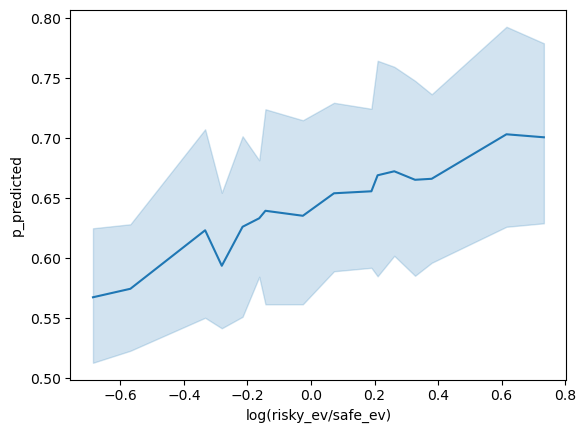

In [6]:
data
model = RiskModelProbabilityDistortion(data, lapse_rate=0.05, distort_magnitudes=False)
model.build_estimation_model()
idata = model.sample(50, 50)

ppc = model.ppc(data, idata)
pred =  ppc.loc['ll_bernoulli'].mean(1).to_frame('p_predicted')
sns.lineplot(pred.reset_index(), x='log(risky_ev/safe_ev)', y='p_predicted')

Only 50 samples in chain.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [magnitude_evidence_sd_mu_untransformed, magnitude_evidence_sd_sd, magnitude_evidence_sd_offset, magnitude_prior_sd_mu_untransformed, magnitude_prior_sd_sd, magnitude_prior_sd_offset]


Sampling 4 chains for 50 tune and 50 draw iterations (200 + 200 draws total) took 2 seconds.
The number of samples is too small to check convergence reliably.
Sampling: [ll_bernoulli]


<Axes: xlabel='log(risky_ev/safe_ev)', ylabel='p_predicted'>

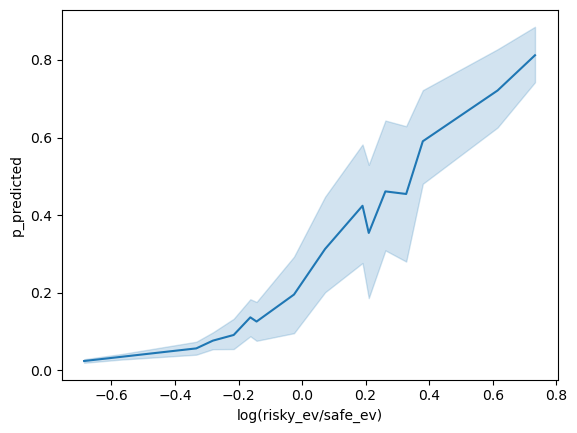

In [4]:
data
model = RiskModelProbabilityDistortion(data, lapse_rate=0.05, distort_probabilities=False)
model.build_estimation_model()
idata = model.sample(50, 50)

ppc = model.ppc(data, idata)
pred =  ppc.loc['ll_bernoulli'].mean(1).to_frame('p_predicted')
sns.lineplot(pred.reset_index(), x='log(risky_ev/safe_ev)', y='p_predicted')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_83410/1643802905.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(idata.posterior['probability_evidence_sd_mu'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_83410/1643802905.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.di

<Axes: xlabel='probability_prior_sd_mu', ylabel='Density'>

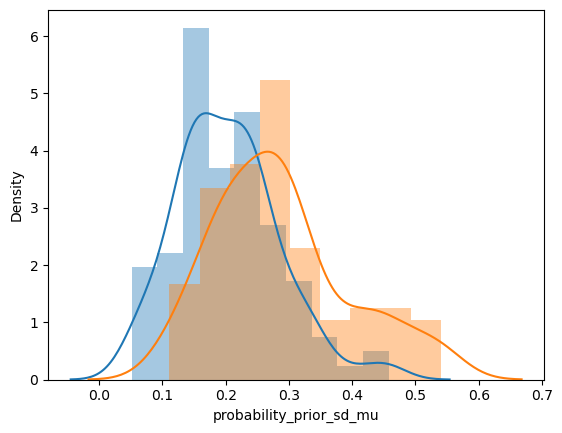

In [95]:
sns.distplot(idata.posterior['probability_evidence_sd_mu'])
sns.distplot(idata.posterior['probability_prior_sd_mu'])

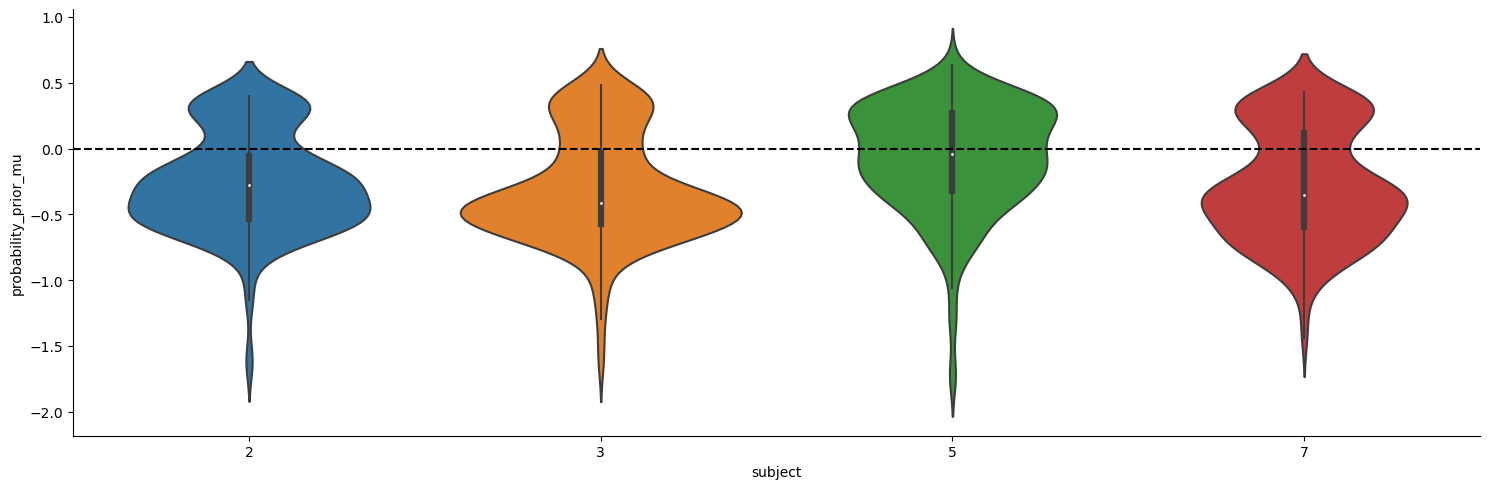

In [82]:
import matplotlib.pyplot as plt
sns.catplot(x='subject', y='probability_prior_mu', data=idata.posterior['probability_prior_mu'].to_dataframe().reset_index(), aspect=3, kind='violin')
# plt.ylim(0, 2)
plt.axhline(0.0, c='k', ls='--')

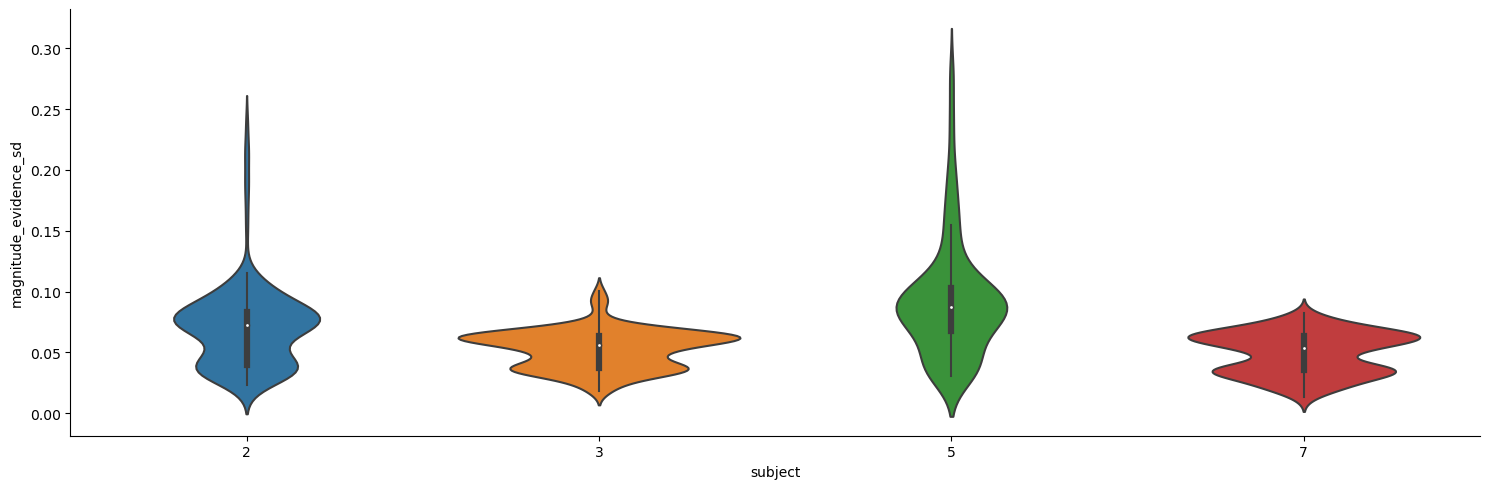

In [84]:
import matplotlib.pyplot as plt
sns.catplot(x='subject', y='magnitude_evidence_sd', data=idata.posterior['magnitude_evidence_sd'].to_dataframe().reset_index(), aspect=3, kind='violin')
# plt.ylim(0, 2)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_83410/1850640687.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(idata.posterior['magnitude_evidence_sd_mu'])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_83410/1850640687.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dist

<Axes: xlabel='magnitude_prior_sd_mu', ylabel='Density'>

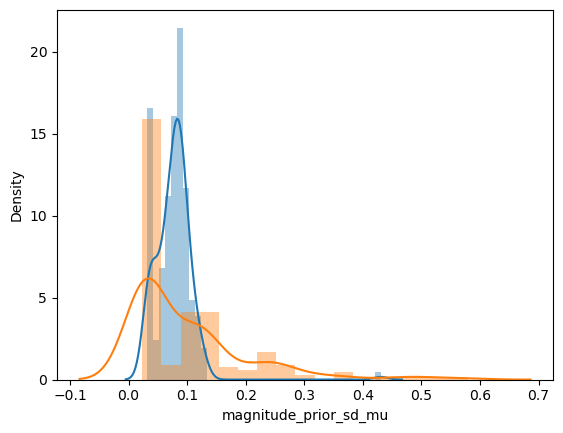

In [85]:
sns.distplot(idata.posterior['magnitude_evidence_sd_mu'])
sns.distplot(idata.posterior['magnitude_prior_sd_mu'])

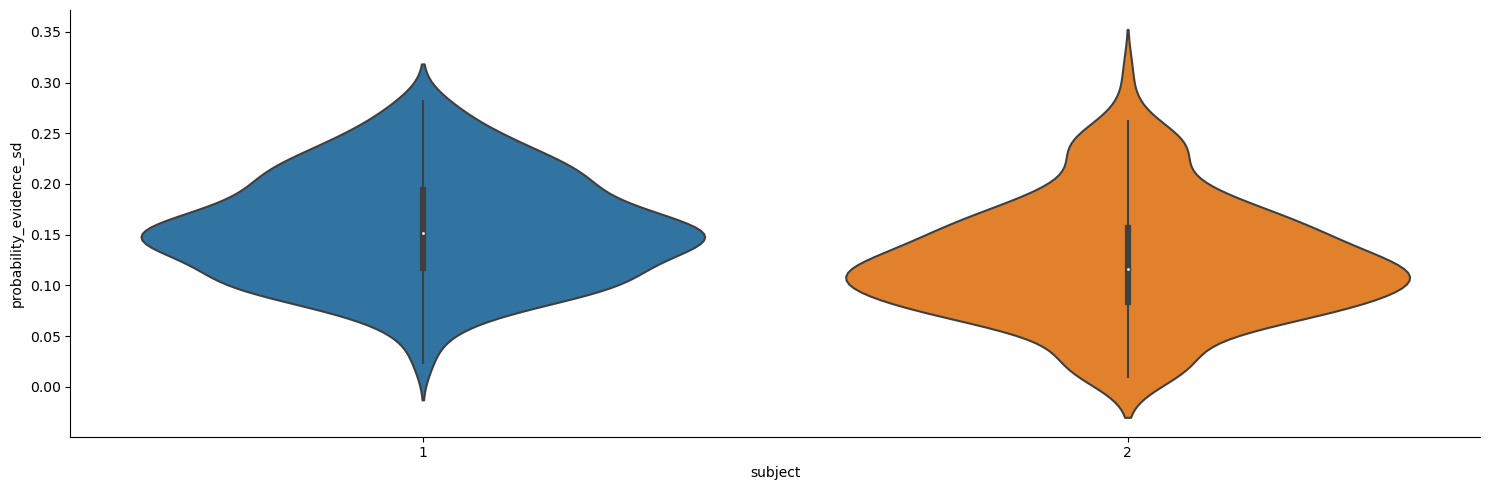

In [23]:
import matplotlib.pyplot as plt
sns.catplot(x='subject', y='probability_evidence_sd', data=idata.posterior['probability_evidence_sd'].to_dataframe().reset_index(), aspect=3, kind='violin')
# plt.ylim(0, 2)

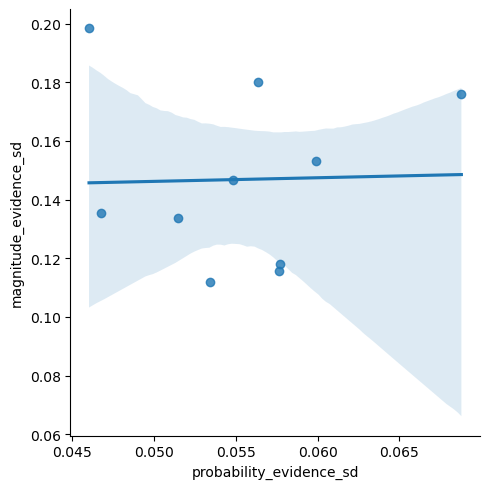

In [ ]:
prob_evidence_sd = idata.posterior['probability_evidence_sd'].to_dataframe()
mag_evidence_sd = idata.posterior['magnitude_evidence_sd'].to_dataframe()

evidence_sd = prob_evidence_sd.join(mag_evidence_sd)


sns.lmplot(x='probability_evidence_sd', y='magnitude_evidence_sd', data=evidence_sd.groupby(['subject']).mean().reset_index())